# Phase 3: NLP Feature Extraction & Machine Learning Prediction Engine

This notebook implements the text-only defect prediction framework evaluating how accurately an LLM's verbal explanations diagnose downstream code compilation and memory safety flaws.

# Relation to XKDD paper:
## Section 4: Feature Extraction
* **Section 4.1 (TF-IDF Encodings):** Text tokenization, stop-word purges, Porter stemming, and vocabulary capping at 300 sparse features per register.
* **Section 4.2 (Sentence-BERT Encodings):** Contextualized 1152-dimensional dense embedding maps.
* **Section 4.3 (Structural & Pedagogical Features):** Numerical featurization of text properties (Type-Token Ratio, Readability, Keyword Alignment Scores).

## Section 5: Experimental Setup
* Sets up stratified 10-fold cross-validation and Leave-One-Model-Out (LOMO) validation bounds.

## Section 6: Evaluation & Ablation Results
* **Section 6.1:** Main predictive performance tables (Random Forest vs. Logistic Regression baselines).
* **Section 6.2:** Channel register ablations (Explanations vs. Hints vs. Summaries).
* **Section 6.3:** Representation family ablations (TF-IDF vs. S-BERT vs. Structural metrics).
* **Section 6.4:** Held-out 80/20 test split operating point performance profiles.

## Section 7.2: Interpretability via SHAP
* TreeExplainer allocation mapping to extract exact lexical risk weight charts.

In [ ]:
# ==========================================
# --- STEP 1: IMPORTS & CONFIGURATION ---
# ==========================================
!pip install -q textstat shap sentence-transformers nltk

import json
import glob
import os
import re
import pandas as pd
import numpy as np
import textstat
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

# --- NLP IMPORTS ---
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# --- VISUALIZATION SETUP ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- FILE PATHS ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

# External (LeetCode) Paths Only
REAL_BASE_DIR = "/content/drive/MyDrive/LLM_Domain_Results/Supplementary Datasets"
REAL_TECH_EVAL_CSV = os.path.join(REAL_BASE_DIR, "Phase3_External_TechEval_Results.csv")
REAL_OUTPUT_FEATURES = os.path.join(REAL_BASE_DIR, "Phase4_External_Validation_Features.csv")

# ==========================================
# --- NLP REGEX PATTERNS & CONSTANTS ---
# ==========================================
# Detects C-syntax leakage in natural language Socratic hints
CODE_LEAK_PATTERN = re.compile(r'(;\s*$|->|\*ptr|malloc\(|printf\()', re.MULTILINE)

# Robustly splits Socratic hints regardless of LLM formatting hallucinations
HINT_SPLIT_PATTERN = re.compile(r'(?i)\bhint\s*#?\d*\b[:\-\.]?|^\s*\d+\.\s*', re.MULTILINE)

# Core concepts to check for Semantic Alignment in the summaries
C_KEYWORDS = ['malloc', 'free', 'struct', 'pointer', 'array', 'while', 'for', 'return', 'int', 'char', 'sizeof']

print("Step 1 Complete: Configurations loaded for LeetCode External Dataset exclusively.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.1 MB/s eta 0:00:00
Mounted at /content/drive
Step 1 Complete: Configurations loaded for LeetCode External Dataset exclusively.


In [ ]:
# ==========================================
# --- STEP 2: LOAD & FILTER EXTERNAL DATASET ---
# ==========================================
print("Loading External (LeetCode) Dataset...")

# 1. Load Phase 3 Technical Evaluation Results
df_tech_ext = pd.read_csv(REAL_TECH_EVAL_CSV)

# 2. Load Phase 2 Text Generation Results
csv_files = [
    'GPTOSS_Phase2_External_Audit_Results.csv',
    'LLAMA_Phase2_External_Audit_Results.csv',
    'KIMIK2_Phase2_External_Audit_Results.csv'
]

text_dfs = []
for file in csv_files:
    file_path = os.path.join(REAL_BASE_DIR, file)
    if os.path.exists(file_path):
        text_dfs.append(pd.read_csv(file_path))
    else:
        print(f"Warning: {file} not found.")

df_text_ext = pd.concat(text_dfs, ignore_index=True)

# ==========================================
# 3. EXTRA: PURGE THE LEFTOVER MENDELEY DATA
# ==========================================
initial_tech_len = len(df_tech_ext)
initial_text_len = len(df_text_ext)

df_tech_ext = df_tech_ext[~df_tech_ext['global_problem_id'].str.contains('MD_', case=False, na=False)].copy()
df_text_ext = df_text_ext[~df_text_ext['global_problem_id'].str.contains('MD_', case=False, na=False)].copy()

print(f"Dropped {initial_tech_len - len(df_tech_ext)} Mendeley rows from Tech Eval.")
print(f"Dropped {initial_text_len - len(df_text_ext)} Mendeley rows from Text Data.")

# 4. Standardize column names for the NLP engine
df_text_ext = df_text_ext.rename(columns={
    'step2_response': 'step2_code',
    'step3_response': 'step3_expl',
    'step4_response': 'step4_hints',
    'step5_response': 'step5_summ',
    'step6_response': 'step6_tests'
})

for step in ['step2_code', 'step3_expl', 'step4_hints', 'step5_summ', 'step6_tests']:
    if step in df_text_ext.columns:
        df_text_ext[step] = df_text_ext[step].fillna('').astype(str)

# Safely drop duplicates in case of weird checkpoint overlaps
df_text_ext = df_text_ext.drop_duplicates(subset=['global_problem_id', 'model_name'])
df_tech_ext = df_tech_ext.drop_duplicates(subset=['global_problem_id', 'model_name'])

# 5. Merge Tech and Text Data
df_external = pd.merge(df_tech_ext, df_text_ext, on=['global_problem_id', 'model_name'], how='inner')

# 6. Create Targets exactly to match the standard dataset
df_external['Target_Compilation'] = (df_external['CompStatus'].astype(str).str.strip().str.upper() == 'PASS').astype(int)
df_external['Target_Memory_UB'] = (
    (df_external['ValgrindStatus'].astype(str).str.strip().str.upper() == 'PASS') &
    (df_external['UBStatus'].astype(str).str.strip().str.upper() == 'PASS')
).astype(int)
df_external['Target_Composite'] = ((df_external['Target_Compilation'] == 1) & (df_external['Target_Memory_UB'] == 1)).astype(int)

print("\n==================================================")
print("EXTERNAL DATASET READY")
print("==================================================")
print(f"Final Merged Rows: {len(df_external)}")
print("==================================================")

Loading External (LeetCode) Dataset...
Dropped 72 Mendeley rows from Tech Eval.
Dropped 72 Mendeley rows from Text Data.

EXTERNAL DATASET READY
Final Merged Rows: 8551


In [ ]:
# ==========================================
# --- STEP 3: ADVANCED NLP EXTRACTION ---
# ==========================================
print("Initializing NLP Models (BERT and Stemmer)...")
stemmer = PorterStemmer()
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

def stem_text(text):
    """Tokenizes and stems text for TF-IDF normalization."""
    if not isinstance(text, str) or not text.strip():
        return ""
    tokens = word_tokenize(text.lower())
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token.isalpha()]
    return " ".join(stemmed_tokens)

def build_nlp_features(df, expl_col, hints_col, summ_col, dataset_name="Dataset"):
    print(f"\n--- Processing NLP Features for {dataset_name} ---")
    df = df.copy()

    # Ensure text is string and fill NaNs
    for col in [expl_col, hints_col, summ_col]:
        df[col] = df[col].fillna("").astype(str)

    # 1. Stemming for TF-IDF
    print("1/3 Applying NLTK Porter Stemmer...")
    stemmed_expl = df[expl_col].apply(stem_text)
    stemmed_hints = df[hints_col].apply(stem_text)
    stemmed_summ = df[summ_col].apply(stem_text)

    # 2. Expanded TF-IDF (max_features=300)
    print("2/3 Generating Expanded TF-IDF Matrices (max_features=300)...")
    tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2), stop_words='english')

    # Fit/Transform separately to maintain artifact isolation
    tfidf_expl = tfidf.fit_transform(stemmed_expl).toarray()
    tfidf_hints = tfidf.fit_transform(stemmed_hints).toarray()
    tfidf_summ = tfidf.fit_transform(stemmed_summ).toarray()

    df_tfidf_expl = pd.DataFrame(tfidf_expl, columns=[f"tfidf_expl_{i}" for i in range(tfidf_expl.shape[1])], index=df.index)
    df_tfidf_hints = pd.DataFrame(tfidf_hints, columns=[f"tfidf_hints_{i}" for i in range(tfidf_hints.shape[1])], index=df.index)
    df_tfidf_summ = pd.DataFrame(tfidf_summ, columns=[f"tfidf_summ_{i}" for i in range(tfidf_summ.shape[1])], index=df.index)

    # 3. Dense BERT Embeddings
    print("3/3 Generating BERT Semantic Embeddings...")
    bert_expl = bert_model.encode(df[expl_col].tolist(), show_progress_bar=True)
    bert_hints = bert_model.encode(df[hints_col].tolist(), show_progress_bar=True)
    bert_summ = bert_model.encode(df[summ_col].tolist(), show_progress_bar=True)

    df_bert_expl = pd.DataFrame(bert_expl, columns=[f"bert_expl_{i}" for i in range(bert_expl.shape[1])], index=df.index)
    df_bert_hints = pd.DataFrame(bert_hints, columns=[f"bert_hints_{i}" for i in range(bert_hints.shape[1])], index=df.index)
    df_bert_summ = pd.DataFrame(bert_summ, columns=[f"bert_summ_{i}" for i in range(bert_summ.shape[1])], index=df.index)

    # 4. Concatenate everything back to the original dataframe
    df_final = pd.concat([
        df,
        df_tfidf_expl, df_tfidf_hints, df_tfidf_summ,
        df_bert_expl, df_bert_hints, df_bert_summ
    ], axis=1)

    print(f"[OK] {dataset_name} NLP Extraction Complete. Final Shape: {df_final.shape}")
    return df_final

# ==========================================
# EXECUTE NLP EXTRACTION ON LEETCODE DATASET
# ==========================================
df_external_final = build_nlp_features(
    df=df_external,
    expl_col="step3_expl",
    hints_col="step4_hints",
    summ_col="step5_summ",
    dataset_name="External (LeetCode)"
)

Initializing NLP Models (BERT and Stemmer)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


--- Processing NLP Features for External (LeetCode) ---
1/3 Applying NLTK Porter Stemmer...
2/3 Generating Expanded TF-IDF Matrices (max_features=300)...
3/3 Generating BERT Semantic Embeddings...


Batches:   0%|          | 0/268 [00:00<?, ?it/s]

Batches:   0%|          | 0/268 [00:00<?, ?it/s]

Batches:   0%|          | 0/268 [00:00<?, ?it/s]

[OK] External (LeetCode) NLP Extraction Complete. Final Shape: (8551, 2070)


In [ ]:
# ==========================================
# --- STEP 4: THE EVALUATION ENGINE ---
# ==========================================
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

def evaluate_features(df, feature_cols, target_col, cv_strategy='StratifiedCV'):
    valid_data = df.dropna(subset=[target_col] + feature_cols).copy()
    X = valid_data[feature_cols].values
    y = valid_data[target_col].values
    models_array = valid_data['model_name'].values

    # Random Forest (100 estimators, depth 10, balanced)
    clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')

    if cv_strategy == 'StratifiedCV':
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        splits = list(cv.split(X, y))
    elif cv_strategy == 'LOMO':
        unique_models = np.unique(models_array)
        splits = []
        for holdout_model in unique_models:
            train_idx = np.where(models_array != holdout_model)[0]
            test_idx = np.where(models_array == holdout_model)[0]
            splits.append((train_idx, test_idx))
    else:
        raise ValueError("Invalid cv_strategy")

    oof_preds = np.zeros(len(y))
    lomo_aucs = {}

    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # Only train if we have both classes in the training set
        if len(np.unique(y_train)) > 1:
            clf.fit(X_train, y_train)
            preds = clf.predict_proba(X_test)[:, 1]
            oof_preds[test_idx] = preds

            if cv_strategy == 'LOMO':
                held_out_model = np.unique(models_array[test_idx])[0]
                if len(np.unique(y_test)) > 1:
                    lomo_aucs[held_out_model] = roc_auc_score(y_test, preds)
                else:
                    lomo_aucs[held_out_model] = np.nan

    # Calculate global metrics
    try:
        global_auc = roc_auc_score(y, oof_preds)
    except ValueError:
        global_auc = np.nan

    cm = confusion_matrix(y, (oof_preds >= 0.5).astype(int))

    return {
        'Global_AUC': global_auc,
        'LOMO_Per_Model_AUCs': lomo_aucs,
        'Confusion_Matrix': cm
    }

print("Step 4 Complete: Clean External Evaluation Engine Loaded (Stratified 10-Fold CV).")

Step 4 Complete: Clean External Evaluation Engine Loaded (Stratified 10-Fold CV).


In [ ]:
# ==========================================
# --- STEP 4b: STRUCTURAL FEATURE EXTRACTION ---
# ==========================================
import textstat
import json
import re

print("Extracting 12 Structural Features...")

# Helper functions
def calc_lex_div(text):
    tokens = str(text).split()
    return len(set(tokens)) / len(tokens) if tokens else 0

def safe_fk(text):
    try: return textstat.flesch_kincaid_grade(str(text))
    except: return 0

def safe_fog(text):
    try: return textstat.gunning_fog(str(text))
    except: return 0

def hint_delta(text):
    parts = str(text).split('\n')
    if len(parts) < 2: return 0
    return safe_fk(parts[-1]) - safe_fk(parts[0])

# 1-4: Explanation Readability & Volume
df_external_final['struct_expl_fk'] = df_external_final['step3_expl'].apply(safe_fk)
df_external_final['struct_expl_fog'] = df_external_final['step3_expl'].apply(safe_fog)
df_external_final['struct_expl_words'] = df_external_final['step3_expl'].apply(lambda x: len(str(x).split()))
df_external_final['struct_expl_lexdiv'] = df_external_final['step3_expl'].apply(calc_lex_div)

# 5-6: Hint/Summ Volume
df_external_final['struct_hint_words'] = df_external_final['step4_hints'].apply(lambda x: len(str(x).split()))
df_external_final['struct_summ_words'] = df_external_final['step5_summ'].apply(lambda x: len(str(x).split()))

# 7: Summary Readability
df_external_final['struct_summ_fk'] = df_external_final['step5_summ'].apply(safe_fk)

# 8: Hint Readability Delta
df_external_final['struct_hint_delta'] = df_external_final['step4_hints'].apply(hint_delta)

# 9: Hint C-Syntax Leakage
c_leak_pattern = re.compile(r'(;\s*$|->|\*ptr|malloc\(|printf\()', re.MULTILINE)
df_external_final['struct_hint_leak'] = df_external_final['step4_hints'].apply(lambda x: 1 if c_leak_pattern.search(str(x)) else 0)

# 10: Summary Alignment Score
c_keywords = ['malloc', 'free', 'struct', 'pointer', 'array', 'while', 'for', 'return', 'int', 'char', 'sizeof']
def get_alignment(row):
    code = str(row['step2_code']).lower()
    summ = str(row['step5_summ']).lower()
    present_in_code = [kw for kw in c_keywords if kw in code]
    if not present_in_code: return 1.0 # default if no C concepts used
    present_in_summ = [kw for kw in present_in_code if kw in summ]
    return len(present_in_summ) / len(present_in_code)
df_external_final['struct_summ_align'] = df_external_final.apply(get_alignment, axis=1)

# 11: Test JSON Validity
def is_valid_json(text):
    try:
        json.loads(str(text))
        return 1
    except: return 0
df_external_final['struct_test_json'] = df_external_final['step6_tests'].apply(is_valid_json)

# 12: Test Constraint Memory Flag
mem_pattern = re.compile(r'(memory|alloc|leak|pointer|free)', re.IGNORECASE)
df_external_final['struct_test_mem'] = df_external_final['step6_tests'].apply(lambda x: 1 if mem_pattern.search(str(x)) else 0)

# Define Model B for the evaluation engine
model_b_struct = [c for c in df_external_final.columns if c.startswith('struct_')]

print(f"[OK] 12 Structural Features Extracted Successfully. (Columns: {len(model_b_struct)})")

Extracting 12 Structural Features...
[OK] 12 Structural Features Extracted Successfully. (Columns: 12)


In [ ]:
# ==========================================
# --- STEP 5: FULL ABLATION & EXTERNAL VALIDATION ---
# ==========================================
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

print("Executing Full Ablation & Validation Experiments...\n")

target = 'Target_Memory_UB'

# IMPORTANT: Filter out compilation failures
df_external_compiled = df_external_final[df_external_final['Target_Compilation'] == 1].copy()

# 1. Define all feature channels
tfidf_expl  = [c for c in df_external_compiled.columns if c.startswith('tfidf_expl_')]
tfidf_hints = [c for c in df_external_compiled.columns if c.startswith('tfidf_hints_')]
tfidf_summ  = [c for c in df_external_compiled.columns if c.startswith('tfidf_summ_')]

bert_expl   = [c for c in df_external_compiled.columns if c.startswith('bert_expl_')]
bert_hints  = [c for c in df_external_compiled.columns if c.startswith('bert_hints_')]
bert_summ   = [c for c in df_external_compiled.columns if c.startswith('bert_summ_')]

# True Model A (All TF-IDF concatenated) and its BERT variant
model_a_tfidf = tfidf_expl + tfidf_hints + tfidf_summ
model_a_bert  = bert_expl + bert_hints + bert_summ

# 2. Run Stratified 10-Fold Ablations
print("--- Running Stratified 10-Fold Ablations ---")
res_expl_gkf  = evaluate_features(df_external_compiled, tfidf_expl, target, cv_strategy='StratifiedCV')
res_hints_gkf = evaluate_features(df_external_compiled, tfidf_hints, target, cv_strategy='StratifiedCV')
res_summ_gkf  = evaluate_features(df_external_compiled, tfidf_summ, target, cv_strategy='StratifiedCV')
res_model_a_gkf = evaluate_features(df_external_compiled, model_a_tfidf, target, cv_strategy='StratifiedCV')
res_bert_a_gkf  = evaluate_features(df_external_compiled, model_a_bert, target, cv_strategy='StratifiedCV')

# 3. Run LOMO for True Model A
print("--- Running LOMO for Model A ---")
res_model_a_lomo = evaluate_features(df_external_compiled, model_a_tfidf, target, cv_strategy='LOMO')

# 4. Print Master Validation Results
print("\n============================================================")
print("EXTERNAL DATASET VALIDATION RESULTS (ROC-AUC)")
print("============================================================")
print("--- Per-Channel Ablation (TF-IDF) ---")
print(f"Explanations Only       | Stratified 10-Fold : {res_expl_gkf['Global_AUC']:.3f}")
print(f"Hints Only              | Stratified 10-Fold : {res_hints_gkf['Global_AUC']:.3f}")
print(f"Summaries Only          | Stratified 10-Fold : {res_summ_gkf['Global_AUC']:.3f}")
print("-" * 60)
print("--- Full Model Comparisons ---")
print(f"Model A (All TF-IDF)    | Stratified 10-Fold : {res_model_a_gkf['Global_AUC']:.3f}")
print(f"Model A (All BERT)      | Stratified 10-Fold : {res_bert_a_gkf['Global_AUC']:.3f}")
print("-" * 60)

# Format the LOMO Per-Model AUCs cleanly
lomo_per_model_str = " | ".join([f"{m}: {auc:.3f}" for m, auc in res_model_a_lomo['LOMO_Per_Model_AUCs'].items() if pd.notna(auc)])

print(f"Model A (All TF-IDF)    | LOMO Average       : {res_model_a_lomo['Global_AUC']:.3f}")
print(f"LOMO Per-Model Breakdown: {lomo_per_model_str}")
print("============================================================\n")

# 5. Print Classification Report Matrix for True Model A
print("==================================================")
print("RANDOM FOREST + TF-IDF (MODEL A) PREDICTION RESULTS")
print("==================================================")
valid_data = df_external_compiled.dropna(subset=[target] + model_a_tfidf)
X_train, X_test, y_train, y_test = train_test_split(
    valid_data[model_a_tfidf], valid_data[target], test_size=0.2, random_state=42, stratify=valid_data[target]
)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.3f}")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=["Safe (0)", "Memory Leak (1)"]))
print("==================================================")

Executing Full Ablation & Validation Experiments...

--- Running Stratified 10-Fold Ablations ---
--- Running LOMO for Model A ---

EXTERNAL DATASET VALIDATION RESULTS (ROC-AUC)
--- Per-Channel Ablation (TF-IDF) ---
Explanations Only       | Stratified 10-Fold : 0.814
Hints Only              | Stratified 10-Fold : 0.778
Summaries Only          | Stratified 10-Fold : 0.805
------------------------------------------------------------
--- Full Model Comparisons ---
Model A (All TF-IDF)    | Stratified 10-Fold : 0.819
Model A (All BERT)      | Stratified 10-Fold : 0.787
------------------------------------------------------------
Model A (All TF-IDF)    | LOMO Average       : 0.765
LOMO Per-Model Breakdown: meta-llama/llama-3.3-70b-instruct: 0.555 | moonshotai/kimi-k2-0905: 0.715 | openai/gpt-oss-120b: 0.770

RANDOM FOREST + TF-IDF (MODEL A) PREDICTION RESULTS
ROC-AUC Score : 0.821
--------------------------------------------------
                 precision    recall  f1-score   support



Generating SHAP Explanations for True Model A (All Channels)...

Calculating SHAP values...


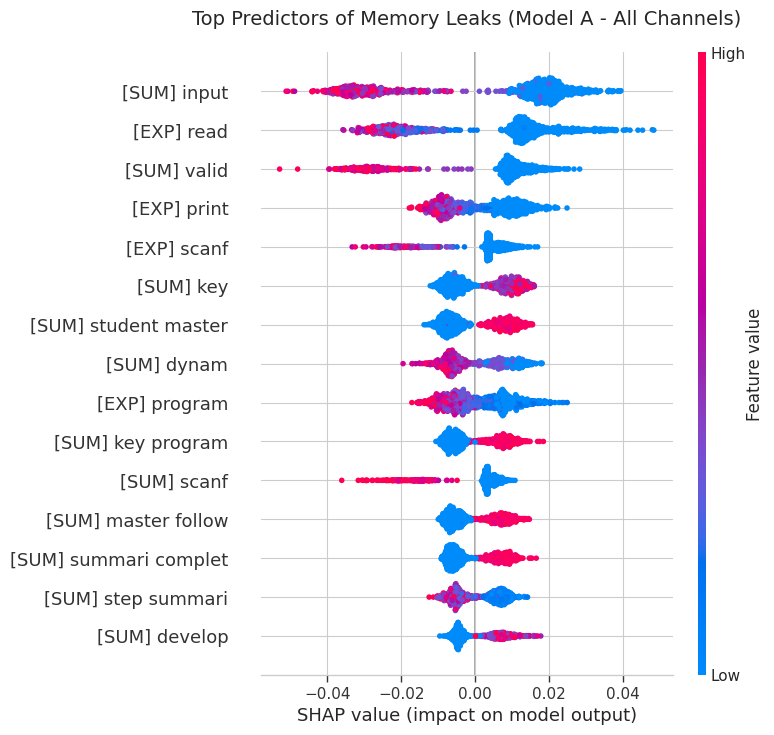


SHAP Extraction Complete!


In [ ]:
# ==========================================
# --- STEP 6: SHAP KNOWLEDGE DISCOVERY ---
# ==========================================
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

print("Generating SHAP Explanations for True Model A (All Channels)...\n")

# 1. Re-fit TF-IDF to extract actual English words for the graph
tfidf_e = TfidfVectorizer(max_features=300, ngram_range=(1, 2), stop_words='english')
tfidf_h = TfidfVectorizer(max_features=300, ngram_range=(1, 2), stop_words='english')
tfidf_s = TfidfVectorizer(max_features=300, ngram_range=(1, 2), stop_words='english')

X_e = tfidf_e.fit_transform(df_external_compiled['step3_expl'].apply(stem_text)).toarray()
X_h = tfidf_h.fit_transform(df_external_compiled['step4_hints'].apply(stem_text)).toarray()
X_s = tfidf_s.fit_transform(df_external_compiled['step5_summ'].apply(stem_text)).toarray()

X_shap = np.hstack([X_e, X_h, X_s])
y_shap = df_external_compiled[target].values

feature_names = (
    [f"[EXP] {w}" for w in tfidf_e.get_feature_names_out()] +
    [f"[HINT] {w}" for w in tfidf_h.get_feature_names_out()] +
    [f"[SUM] {w}" for w in tfidf_s.get_feature_names_out()]
)

# 2. Train Model
rf_shap = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
rf_shap.fit(X_shap, y_shap)

# 3. Calculate SHAP (sampling 1000 to prevent RAM crashes)
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(rf_shap)
X_sample = shap.sample(X_shap, 1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# --- Textract the 2D array for Class 1 (Memory Leaks) ---
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# 4. Plot
plt.figure(figsize=(10, 8))
plt.title("Top Predictors of Memory Leaks (Model A - All Channels)", fontsize=14, pad=20)
# Pass the correctly sliced 2D array to force the beeswarm plot
shap.summary_plot(shap_values_to_plot, X_sample, feature_names=feature_names, max_display=15, show=False)
plt.tight_layout()
plt.show()

print("\nSHAP Extraction Complete!")

In [ ]:
# ==========================================
# --- STEP 7: TRIVIAL BASELINE (LENGTH ONLY) ---
# ==========================================
from sklearn.model_selection import StratifiedKFold

print("Running Trivial Baseline (Text Length Only)...\n")

# Calculate total length of the verbal output
df_external_compiled['total_length'] = (
    df_external_compiled['step3_expl'].str.len() +
    df_external_compiled['step4_hints'].str.len() +
    df_external_compiled['step5_summ'].str.len()
)

X_len = df_external_compiled[['total_length']].values
y_len = df_external_compiled[target].values

rf_len = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

oof_preds_len = np.zeros(len(y_len))
for train_idx, test_idx in cv.split(X_len, y_len):
    rf_len.fit(X_len[train_idx], y_len[train_idx])
    oof_preds_len[test_idx] = rf_len.predict_proba(X_len[test_idx])[:, 1]

base_auc = roc_auc_score(y_len, oof_preds_len)

print("============================================================")
print("TRIVIAL BASELINE RESULTS (Memory Leaks | Stratified 10-Fold)")
print("============================================================")
print(f"Token-Count-Only Baseline (RF) : {base_auc:.3f}")
print(f"Reference: Model A (TF-IDF)    : 0.819")
print("============================================================")

Running Trivial Baseline (Text Length Only)...

TRIVIAL BASELINE RESULTS (Memory Leaks | Stratified 10-Fold)
Token-Count-Only Baseline (RF) : 0.695
Reference: Model A (TF-IDF)    : 0.819


Generating Final Classification Report & Confusion Matrix for Model A (10-Fold CV)...

BEST CONFIGURATION: MODEL A (10-FOLD CV RESULTS)
                 precision    recall  f1-score   support

       Safe (0)       0.72      0.73      0.73      2929
Memory Leak (1)       0.75      0.74      0.74      3170

       accuracy                           0.73      6099
      macro avg       0.73      0.73      0.73      6099
   weighted avg       0.73      0.73      0.73      6099




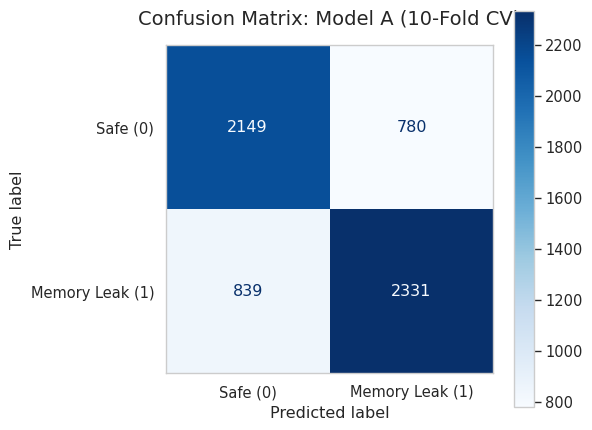

In [ ]:
# ==========================================
# --- STEP 8: BEST CONFIGURATION (MODEL A) CONFUSION MATRIX ---
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

print("Generating Final Classification Report & Confusion Matrix for Model A (10-Fold CV)...\n")

# Use True Model A (Best Configuration)
X_best = df_external_compiled[model_a_tfidf].values
y_best = df_external_compiled[target].values

rf_best = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Arrays to hold Out-Of-Fold predictions
oof_preds_classes = np.zeros(len(y_best))

# Run the 10-Fold CV to get true cross-validated class predictions
for train_idx, test_idx in cv.split(X_best, y_best):
    rf_best.fit(X_best[train_idx], y_best[train_idx])
    # Threshold 0.5 prediction
    oof_preds_classes[test_idx] = rf_best.predict(X_best[test_idx])

# Calculate Confusion Matrix
cm = confusion_matrix(y_best, oof_preds_classes)

print("==================================================")
print("BEST CONFIGURATION: MODEL A (10-FOLD CV RESULTS)")
print("==================================================")
print(classification_report(y_best, oof_preds_classes, target_names=["Safe (0)", "Memory Leak (1)"]))
print("==================================================\n")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe (0)", "Memory Leak (1)"])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.grid(False)
plt.title("Confusion Matrix: Model A (10-Fold CV)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Running Full Feature Family Ablation...

Evaluating Task 1 (Compilation)...
Evaluating Task 2 (Memory Safety)...

TABLE: FEATURE FAMILY ABLATION (ROC-AUC)
Feature Set               | Task 1 (Compile)   | Task 2 (Memory)
------------------------------------------------------------
Model A (TF-IDF All)      | 0.830              | 0.819
Model A (BERT All)        | 0.800              | 0.787
Model B (Structural)      | 0.779              | 0.753
Model C (Combined)        | 0.831              | 0.821

Generating Figure for ROC Curves...


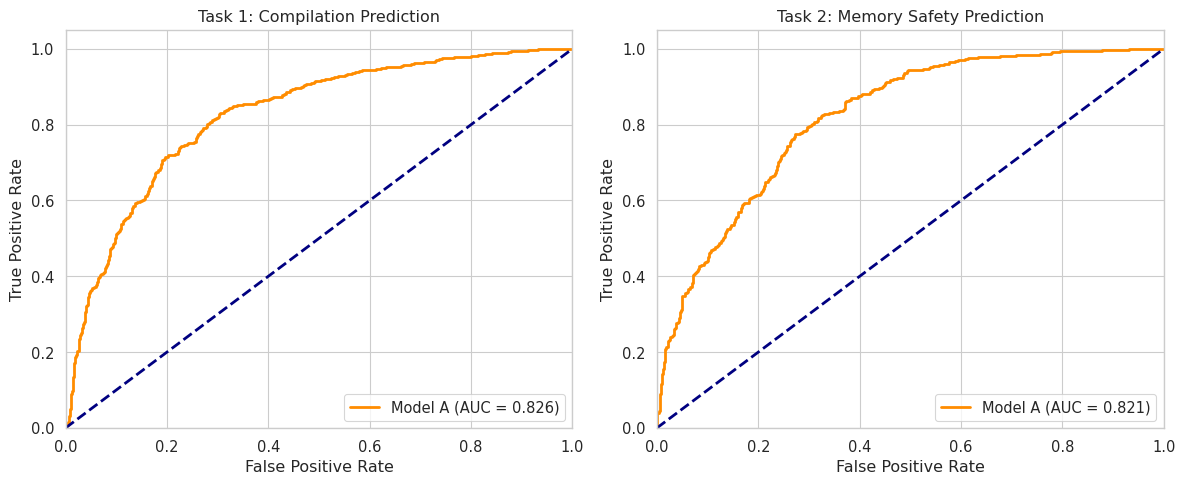

In [ ]:
# ==========================================
# --- STEP 9: ABLATION ---
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Running Full Feature Family Ablation...\n")

# Define Feature Sets
model_a = model_a_tfidf
model_a_bert = model_a_bert
model_b = model_b_struct
model_c = model_a_tfidf + model_b_struct

# --- EVALUATE TASK 1: COMPILATION (Full Dataset) ---
print("Evaluating Task 1 (Compilation)...")
res_t1_a = evaluate_features(df_external_final, model_a, 'Target_Compilation', cv_strategy='StratifiedCV')
res_t1_bert = evaluate_features(df_external_final, model_a_bert, 'Target_Compilation', cv_strategy='StratifiedCV')
res_t1_b = evaluate_features(df_external_final, model_b, 'Target_Compilation', cv_strategy='StratifiedCV')
res_t1_c = evaluate_features(df_external_final, model_c, 'Target_Compilation', cv_strategy='StratifiedCV')

# --- EVALUATE TASK 2: MEMORY SAFETY (Compiled Subset) ---
print("Evaluating Task 2 (Memory Safety)...")
res_t2_a = evaluate_features(df_external_compiled, model_a, 'Target_Memory_UB', cv_strategy='StratifiedCV')
res_t2_bert = evaluate_features(df_external_compiled, model_a_bert, 'Target_Memory_UB', cv_strategy='StratifiedCV')
res_t2_b = evaluate_features(df_external_compiled, model_b, 'Target_Memory_UB', cv_strategy='StratifiedCV')
res_t2_c = evaluate_features(df_external_compiled, model_c, 'Target_Memory_UB', cv_strategy='StratifiedCV')

print("\n==================================================")
print("TABLE: FEATURE FAMILY ABLATION (ROC-AUC)")
print("==================================================")
print(f"{'Feature Set':<25} | {'Task 1 (Compile)':<18} | {'Task 2 (Memory)'}")
print("-" * 60)
print(f"{'Model A (TF-IDF All)':<25} | {res_t1_a['Global_AUC']:.3f}              | {res_t2_a['Global_AUC']:.3f}")
print(f"{'Model A (BERT All)':<25} | {res_t1_bert['Global_AUC']:.3f}              | {res_t2_bert['Global_AUC']:.3f}")
print(f"{'Model B (Structural)':<25} | {res_t1_b['Global_AUC']:.3f}              | {res_t2_b['Global_AUC']:.3f}")
print(f"{'Model C (Combined)':<25} | {res_t1_c['Global_AUC']:.3f}              | {res_t2_c['Global_AUC']:.3f}")
print("==================================================\n")

# --- PLOT FIGURE (ROC CURVES) ---
print("Generating Figure for ROC Curves...")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_roc(ax, df, features, target, title):
    valid_data = df.dropna(subset=[target] + features)
    X = valid_data[features].values
    y = valid_data[target].values

    # 80/20 split just to generate a clean, continuous curve for the figure
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Model A (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc="lower right")

plot_roc(axes[0], df_external_final, model_a, 'Target_Compilation', 'Task 1: Compilation Prediction')
plot_roc(axes[1], df_external_compiled, model_a, 'Target_Memory_UB', 'Task 2: Memory Safety Prediction')

plt.tight_layout()
plt.show()

Evaluating Logistic Regression vs Random Forest for paper Figure...



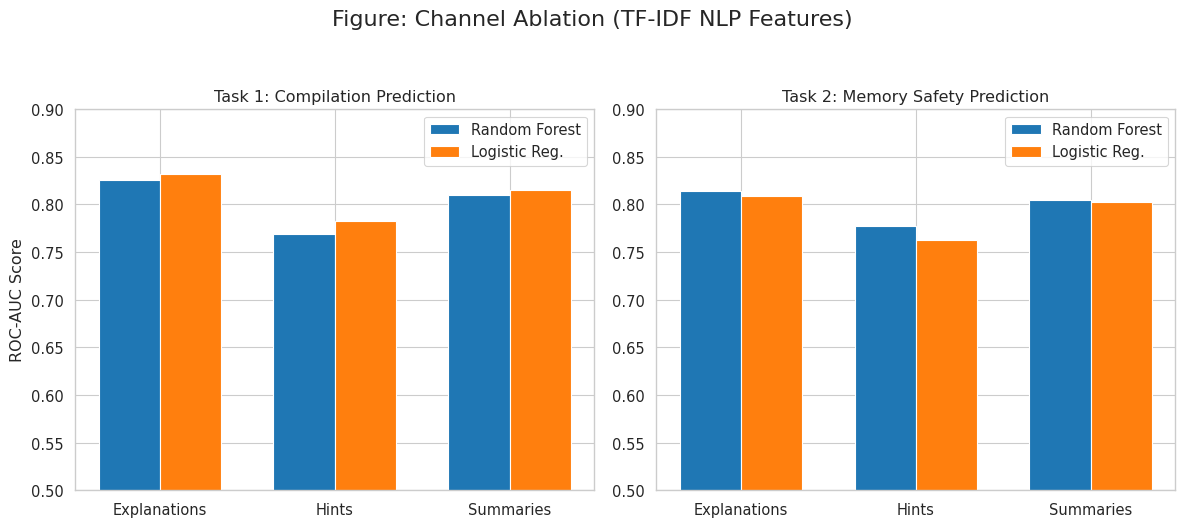

Figure successfully generated!


In [ ]:
# ==========================================
# --- STEP 10: FIGURE (CHANNEL ABLATION BAR CHART) & LR BASELINE ---
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("Evaluating Logistic Regression vs Random Forest for paper Figure...\n")

def get_auc_rf_lr(df, features, target):
    """Evaluates both RF and LR using Stratified 10-Fold CV"""
    valid_data = df.dropna(subset=[target] + features)
    X = valid_data[features].values
    y = valid_data[target].values

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')

    rf_preds, lr_preds = np.zeros(len(y)), np.zeros(len(y))

    for train_idx, test_idx in cv.split(X, y):
        # Fit & Predict RF
        rf.fit(X[train_idx], y[train_idx])
        rf_preds[test_idx] = rf.predict_proba(X[test_idx])[:, 1]

        # Fit & Predict LR
        lr.fit(X[train_idx], y[train_idx])
        lr_preds[test_idx] = lr.predict_proba(X[test_idx])[:, 1]

    return roc_auc_score(y, rf_preds), roc_auc_score(y, lr_preds)

# Calculate scores for Task 1 (Compilation) - Full Dataset
auc_t1_exp_rf, auc_t1_exp_lr = get_auc_rf_lr(df_external_final, tfidf_expl, 'Target_Compilation')
auc_t1_hnt_rf, auc_t1_hnt_lr = get_auc_rf_lr(df_external_final, tfidf_hints, 'Target_Compilation')
auc_t1_sum_rf, auc_t1_sum_lr = get_auc_rf_lr(df_external_final, tfidf_summ, 'Target_Compilation')

# Calculate scores for Task 2 (Memory Safety) - Compiled Subset Only
auc_t2_exp_rf, auc_t2_exp_lr = get_auc_rf_lr(df_external_compiled, tfidf_expl, 'Target_Memory_UB')
auc_t2_hnt_rf, auc_t2_hnt_lr = get_auc_rf_lr(df_external_compiled, tfidf_hints, 'Target_Memory_UB')
auc_t2_sum_rf, auc_t2_sum_lr = get_auc_rf_lr(df_external_compiled, tfidf_summ, 'Target_Memory_UB')

# --- PLOT FIGURE ---
labels = ['Explanations', 'Hints', 'Summaries']
rf_t1 = [auc_t1_exp_rf, auc_t1_hnt_rf, auc_t1_sum_rf]
lr_t1 = [auc_t1_exp_lr, auc_t1_hnt_lr, auc_t1_sum_lr]
rf_t2 = [auc_t2_exp_rf, auc_t2_hnt_rf, auc_t2_sum_rf]
lr_t2 = [auc_t2_exp_lr, auc_t2_hnt_lr, auc_t2_sum_lr]

x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Compilation
axes[0].bar(x - width/2, rf_t1, width, label='Random Forest', color='#1f77b4')
axes[0].bar(x + width/2, lr_t1, width, label='Logistic Reg.', color='#ff7f0e')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('Task 1: Compilation Prediction')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.5, 0.9)
axes[0].legend()

# Panel 2: Memory Safety
axes[1].bar(x - width/2, rf_t2, width, label='Random Forest', color='#1f77b4')
axes[1].bar(x + width/2, lr_t2, width, label='Logistic Reg.', color='#ff7f0e')
axes[1].set_title('Task 2: Memory Safety Prediction')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0.5, 0.9)
axes[1].legend()

plt.suptitle('Figure: Channel Ablation (TF-IDF NLP Features)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

print("Figure successfully generated!")

In [ ]:
# ==========================================
# --- GENERATE TABLE 1 (DATASET STATISTICS) ---
# ==========================================
print("Generating Table 1\n")

# Calculate word counts for the text channels
df_external_final['expl_words'] = df_external_final['step3_expl'].apply(lambda x: len(str(x).split()))
df_external_final['hint_words'] = df_external_final['step4_hints'].apply(lambda x: len(str(x).split()))
df_external_final['summ_words'] = df_external_final['step5_summ'].apply(lambda x: len(str(x).split()))

# Group by model to get the stats
table1 = df_external_final.groupby('model_name').agg(
    Total_Pairs=('global_problem_id', 'count'),
    Compile_Pass=('Target_Compilation', 'sum'),
    Compile_Pass_Pct=('Target_Compilation', lambda x: (x.mean() * 100).round(1)),
    Mean_Expl_Words=('expl_words', lambda x: x.mean().round(1)),
    Mean_Hint_Words=('hint_words', lambda x: x.mean().round(1)),
    Mean_Summ_Words=('summ_words', lambda x: x.mean().round(1))
).reset_index()

# Calculate Memory Safe count (only for rows that compiled)
mem_safe_stats = df_external_compiled.groupby('model_name').agg(
    Memory_Safe=('Target_Memory_UB', 'sum'),
    Memory_Safe_Pct=('Target_Memory_UB', lambda x: (x.mean() * 100).round(1))
).reset_index()

# Merge and display
table1 = pd.merge(table1, mem_safe_stats, on='model_name', how='left')

# Reorder columns for clear display
table1 = table1[['model_name', 'Total_Pairs', 'Compile_Pass', 'Compile_Pass_Pct', 'Memory_Safe', 'Memory_Safe_Pct', 'Mean_Expl_Words', 'Mean_Hint_Words', 'Mean_Summ_Words']]

print(table1.to_string(index=False))

Generating Table 1

                       model_name  Total_Pairs  Compile_Pass  Compile_Pass_Pct  Memory_Safe  Memory_Safe_Pct  Mean_Expl_Words  Mean_Hint_Words  Mean_Summ_Words
meta-llama/llama-3.3-70b-instruct         2868          2640              92.1         1969             74.6            625.0            291.2            192.1
          moonshotai/kimi-k2-0905         2868          1432              49.9          637             44.5            545.2            154.0             94.5
              openai/gpt-oss-120b         2815          2027              72.0          564             27.8           1091.1            187.4            163.9


In [ ]:
# ==========================================
# --- STEP 11: GENERATE REMAINING TABLES ---
# ==========================================
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

print("Calculating 10-Fold CV Mean ± Std for Tables 3 & 4...\n")

def get_cv_metrics(df, features, target):
    """Calculates Mean ± Std AUC for RF and LR over 10 folds"""
    valid_data = df.dropna(subset=[target] + features)
    X = valid_data[features].values
    y = valid_data[target].values

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')

    rf_aucs, lr_aucs = [], []

    for train_idx, test_idx in cv.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        if len(np.unique(y_test)) > 1:
            rf.fit(X_train, y_train)
            rf_aucs.append(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

            lr.fit(X_train, y_train)
            lr_aucs.append(roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

    return f"{np.mean(rf_aucs):.3f} \\pm {np.std(rf_aucs):.3f}", f"{np.mean(lr_aucs):.3f} \\pm {np.std(lr_aucs):.3f}"

configs = {
    "TF-IDF Expl.": tfidf_expl,
    "TF-IDF Hints": tfidf_hints,
    "TF-IDF Summ.": tfidf_summ,
    "TF-IDF All (Model A)": model_a_tfidf,
    "BERT All": model_a_bert,
    "Structural (Model B)": model_b_struct,
    "Combined (Model C)": model_a_tfidf + model_b_struct
}

# Process Task 1
t1_results = {}
for name, feats in configs.items():
    t1_results[name] = get_cv_metrics(df_external_final, feats, 'Target_Compilation')

# Process Task 2
t2_results = {}
for name, feats in configs.items():
    t2_results[name] = get_cv_metrics(df_external_compiled, feats, 'Target_Memory_UB')

# --- GENERATE LATEX FOR TABLES IN OVERLEAF ---
latex_t3 = """
\\begin{table}[t]
    \\centering
    \\small
    \\renewcommand{\\arraystretch}{1.2}
    \\caption{Main Results — Task 1 (Compilation Prediction). 10-fold cross-validated ROC-AUC scores.}
    \\label{tab:task1_results}
    \\begin{tabular*}{0.48\\textwidth}{@{\\extracolsep{\\fill}} l c c @{}}
        \\toprule
        \\textbf{Feature Set} & \\textbf{RF AUC (Mean $\\pm$ SD)} & \\textbf{LR AUC (Mean $\\pm$ SD)} \\\\
        \\midrule
"""
for name in configs.keys():
    rf_str, lr_str = t1_results[name]
    latex_t3 += f"        {name} & ${rf_str}$ & ${lr_str}$ \\\\\n"
latex_t3 += """        \\bottomrule
    \\end{tabular*}
\\end{table}
"""

latex_t4 = """
\\begin{table}[t]
    \\centering
    \\small
    \\renewcommand{\\arraystretch}{1.2}
    \\caption{Main Results — Task 2 (Memory-Safety Prediction). 10-fold cross-validated ROC-AUC scores on the compiled subset.}
    \\label{tab:task2_results}
    \\begin{tabular*}{0.48\\textwidth}{@{\\extracolsep{\\fill}} l c c @{}}
        \\toprule
        \\textbf{Feature Set} & \\textbf{RF AUC (Mean $\\pm$ SD)} & \\textbf{LR AUC (Mean $\\pm$ SD)} \\\\
        \\midrule
"""
for name in configs.keys():
    rf_str, lr_str = t2_results[name]
    latex_t4 += f"        {name} & ${rf_str}$ & ${lr_str}$ \\\\\n"
latex_t4 += """        \\bottomrule
    \\end{tabular*}
\\end{table}
"""

print("=========================================")
print("LATEX CODE FOR TASK 1")
print("=========================================")
print(latex_t3)
print("\n=========================================")
print("LATEX CODE FOR TASK 2")
print("=========================================")
print(latex_t4)

Calculating 10-Fold CV Mean ± Std for Tables 3 & 4...

LATEX CODE FOR TASK 1

\begin{table}[t]
    \centering
    \small
    \renewcommand{\arraystretch}{1.2}
    \caption{Main Results — Task 1 (Compilation Prediction). 10-fold cross-validated ROC-AUC scores.}
    \label{tab:task1_results}
    \begin{tabular*}{0.48\textwidth}{@{\extracolsep{\fill}} l c c @{}}
        \toprule
        \textbf{Feature Set} & \textbf{RF AUC (Mean $\pm$ SD)} & \textbf{LR AUC (Mean $\pm$ SD)} \\
        \midrule
        TF-IDF Expl. & $0.826 \pm 0.017$ & $0.832 \pm 0.019$ \\
        TF-IDF Hints & $0.769 \pm 0.020$ & $0.783 \pm 0.018$ \\
        TF-IDF Summ. & $0.810 \pm 0.017$ & $0.816 \pm 0.015$ \\
        TF-IDF All (Model A) & $0.831 \pm 0.016$ & $0.836 \pm 0.017$ \\
        BERT All & $0.801 \pm 0.018$ & $0.822 \pm 0.015$ \\
        Structural (Model B) & $0.779 \pm 0.014$ & $0.742 \pm 0.022$ \\
        Combined (Model C) & $0.831 \pm 0.016$ & $0.840 \pm 0.017$ \\
        \bottomrule
    \end{tabular*}